In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMAGE_PATH = "./images_week1/dark2.png"

In [16]:
img = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError(f"Cannot read image: {IMAGE_PATH}")

print(f"shape   : {img.shape}")
print(f"dtype   : {img.dtype}")
print(f"min/max : {img.min()} / {img.max()}")

shape   : (700, 700)
dtype   : uint8
min/max : 2 / 50


In [17]:
img_float = img.astype(np.float32)

c = 255.0 / np.log1p(img_float.max())
log_img = c * np.log1p(img_float)
log_img = np.clip(log_img, 0, 255).astype(np.uint8)

print(f"c = {c:.2f}")


c = 64.86


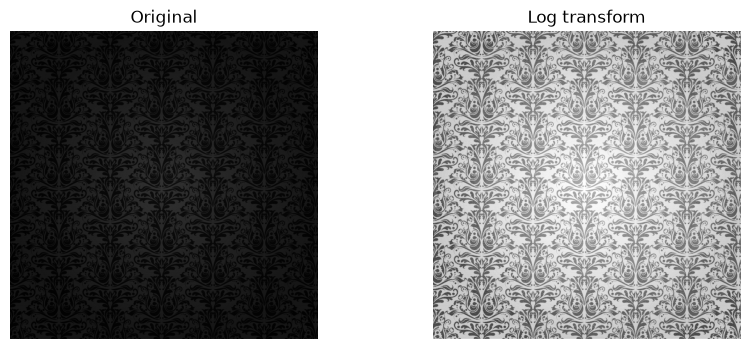

In [18]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(log_img, cmap="gray", vmin=0, vmax=255)
plt.title("Log transform")
plt.axis("off")

plt.show()


In [ ]:
muls = cv2.hconcat([img, log_img])
plt.figure(figsize=(10, 4))
plt.subplot(1, 1, 1)
plt.imshow(muls, cmap="gray", vmin=0, vmax=255)
plt.title("Concat")
plt.axis("off")
# cv2.imshow("title", muls)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

In [ ]:
x = np.arange(256 ,dtype = np.float32)
y = np.log1p(x) / np.log1p(x.max())
# print(y)
print(np.log1p(img.max()))


3.932


# mean_filtering_chapter.ipynb
/Users/tytanasertmac/aider/typroject/ru/code/RUProject/3401/mean_filtering_chapter.ipynb

In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [31]:
def show_image(image, title):
    plt.figure(figsize=(5, 5))
    plt.imshow(image, cmap="gray", vmin=0, vmax=255)
    plt.title(title)
    plt.axis("off")
    plt.show()


def show_images(images, titles):
    count = len(images)
    plt.figure(figsize=(4 * count, 4))

    for i in range(count):
        plt.subplot(1, count, i + 1)
        plt.imshow(images[i], cmap="gray", vmin=0, vmax=255)
        plt.title(titles[i])
        plt.axis("off")

    plt.show()

ชนิดข้อมูล: uint8
ขนาดภาพ: (512, 512)


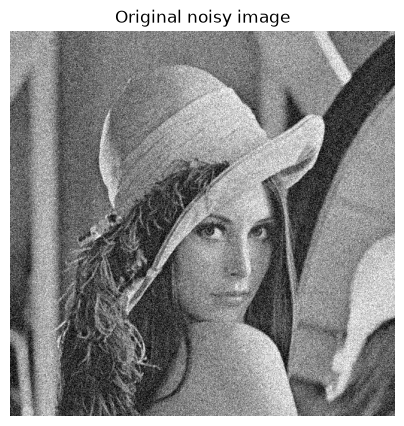

In [32]:
image_path = "./images_week3/lena_noise_512.png"

try:
    gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if gray is None:
        raise FileNotFoundError("ไม่พบไฟล์รูปภาพ: " + image_path)

except Exception as error:
    print("เกิดข้อผิดพลาดในการอ่านไฟล์รูปภาพ")
    raise error

print("ชนิดข้อมูล:", gray.dtype)
print("ขนาดภาพ:", gray.shape)

show_image(gray, "Original noisy image")

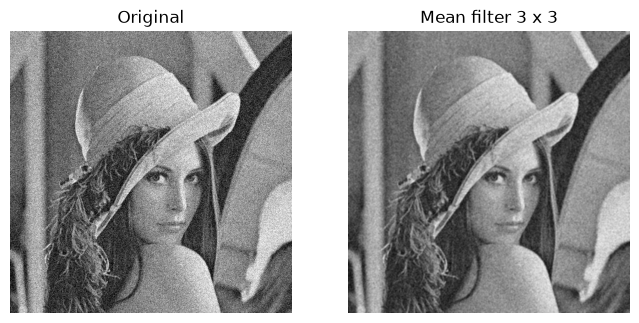

In [36]:
k = 3
mean_cv = cv2.blur(gray, (k, k))

show_images(
    [gray, mean_cv],
    ["Original", "Mean filter 3 x 3"]
)

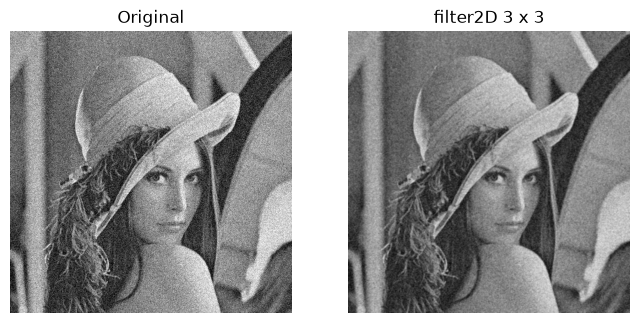

In [ ]:
def mean_filter_with_kernel(image, kernel):
    result = cv2.filter2D(image, -1, kernel)
    return result.astype(np.uint8)


k = 3
# kernel_3x3 = np.ones((k, k), dtype=np.float32) / (k * k)
kernel_3x3 = np.array([[1,1,1],[2,4,2],[1,2,1]], dtype=np.float32) / 16.0 #แบบใหม่ ให้ความสำคัญกับพิกเซลแถวเดียวกันมากขึ้น
mean_filter2d = mean_filter_with_kernel(gray, kernel_3x3)

show_images(
    [gray, mean_filter2d],
    ["Original", "filter2D 3 x 3"]
)

In [ ]:
def mean_filter_manual(image, k):
    border = k // 2
    height, width = image.shape
    output = image.copy()

    for row in range(border, height - border):
        for col in range(border, width - border):
            area = image[
                row - border : row + border + 1,
                col - border : col + border + 1
            ]
            output[row, col] = int(np.mean(area))

    return output


mean_manual = mean_filter_manual(gray, 3)

show_images(
    [gray, mean_cv, mean_manual],
    ["Original", "cv2.blur", "Manual mean filter"]
)

In [ ]:
mean_3 = cv2.blur(gray, (3, 3))
mean_5 = cv2.blur(gray, (5, 5))
mean_9 = cv2.blur(gray, (9, 9))

show_images(
    [gray, mean_3, mean_5, mean_9],
    ["Original", "3 x 3", "5 x 5", "9 x 9"]
)